In [1]:
!pip install pennylane
import pennylane as qml
import matplotlib.pyplot as plt
import numpy as np

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 63.8 MB/s eta 0:00:00


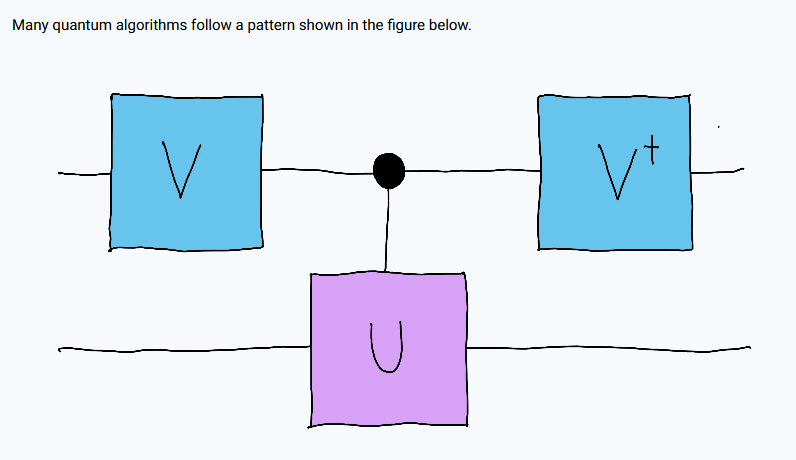

In [2]:
dev = qml.device("default.qubit")

def do(k):

    qml.StatePrep([1,k], wires = [0], normalize = True)

def apply(theta):

    qml.IsingXX(theta, wires = [1,2])

@qml.qnode(dev)
def do_apply_undo(k,theta):
    """
    Applies V, controlled-U, and the inverse of V
    Args:
    - k, theta: The parameters for do and apply (V and U) respectively
    Returns:
    - (np.array): The output state of the routine
    """

    do(k)
    qml.ctrl(apply, control=0)(theta)
    qml.adjoint(do)(k)

    return qml.state()

k, theta = 0.5, 0.8

print("The output state is: \n", do_apply_undo(k, theta))

The output state is: 
 [ 0.9842122+0.j          0.       +0.j          0.       +0.j
  0.       -0.07788367j -0.0315756+0.j          0.       +0.j
  0.       +0.j          0.       -0.15576734j]
